# NLP + Finance: Exploratory Data Analysis

This notebook explores the Financial PhraseBank dataset — 
~4,800 financial news headlines annotated with sentiment labels.

**Goal:** Understand the data before building any models.
- What does the class distribution look like?
- Are there class imbalance issues?
- What do positive, negative, and neutral headlines look like?

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/raw/all-data.csv', 
                 encoding='latin-1', 
                 header=None,
                 names=['sentiment', 'headline'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (4846, 2)

First 5 rows:
  sentiment                                           headline
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...


sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Class percentages:
sentiment
neutral     59.4
positive    28.1
negative    12.5
Name: count, dtype: float64


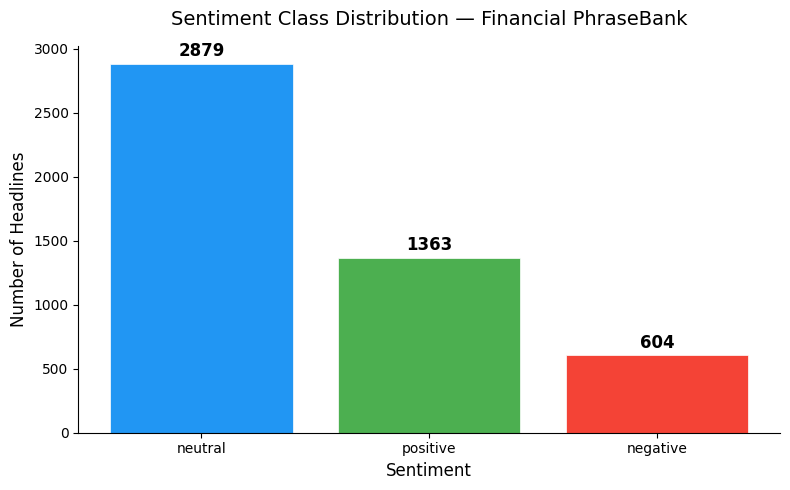

Chart saved to images/


In [2]:
import matplotlib.pyplot as plt

# Count each sentiment class
class_counts = df['sentiment'].value_counts()
print(class_counts)
print(f"\nClass percentages:")
print((class_counts / len(df) * 100).round(1))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#F44336']
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Sentiment Class Distribution — Financial PhraseBank', fontsize=14, pad=15)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Headlines', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

## What I notice about the class distribution

The dataset is significantly imbalanced. Neutral headlines dominate 
at 59.4%, positive makes up 28.1%, and negative is the smallest 
class at just 12.5%.

This matters because a model trained on this data without adjustment 
could learn to just predict "neutral" most of the time and still 
look accurate. That's why I'll use weighted F1-score as my primary 
evaluation metric rather than accuracy - it penalizes the model 
for ignoring rare classes.

The negative class being the smallest is actually the most 
important one for trading because - a model that misses negative news 
could generate bad BUY signals at the worst time.